In [ ]:
import os
os.chdir(r'c:\Users\QQ\OneDrive\桌面\课程设计报告_Lendingclub\ipynb文件（代码和输出结果）')

In [2]:
import pandas as pd
df = pd.read_csv("loan_normalized.csv")
df.head(10)

,loan_amnt,term,emp_length,home_ownership,annual_inc,verification_status,issue_d,loan_status,dti,delinq_2yrs,...,collection_recovery_fee,last_credit_pull_d,collections_12_mths_ex_med,acc_now_delinq,tot_coll_amt,tot_cur_bal,total_rev_hi_lim,purpose_,addr_state_,grade
0,0.130435,0.0,1.00,0.4,0.002526,0.5,0.470588,0.000000,0.002765,0.0,...,0.000000,0.000000,0.0,0.0,0.0,0.0,0.003207,0.076923,0.06,2
1,0.057971,1.0,0.05,0.4,0.003158,0.0,0.470588,1.000000,0.000100,0.0,...,0.000159,0.269231,0.0,0.0,0.0,0.0,0.003207,0.000000,0.20,3
2,0.055072,0.0,1.00,0.4,0.001290,1.0,0.470588,0.000000,0.000872,0.0,...,0.000000,0.000000,0.0,0.0,0.0,0.0,0.003207,0.846154,0.28,3
3,0.275362,0.0,1.00,0.4,0.005179,0.0,0.470588,0.000000,0.002000,0.0,...,0.000000,0.115385,0.0,0.0,0.0,0.0,0.003207,0.692308,0.08,3
4,0.072464,1.0,0.10,0.4,0.008421,0.0,0.470588,0.111111,0.001794,0.0,...,0.000000,0.000000,0.0,0.0,0.0,0.0,0.003207,0.692308,0.74,2
5,0.130435,0.0,0.30,0.4,0.003789,0.0,0.470588,0.000000,0.001120,0.0,...,0.000000,0.038462,0.0,0.0,0.0,0.0,0.003207,1.000000,0.06,1
6,0.188406,1.0,0.80,0.4,0.004948,1.0,0.470588,0.111111,0.002351,0.0,...,0.000000,0.000000,0.0,0.0,0.0,0.0,0.003207,0.153846,0.54,3
7,0.072464,0.0,0.90,0.4,0.005053,0.0,0.470588,0.000000,0.000535,0.0,...,0.000000,0.125000,0.0,0.0,0.0,0.0,0.003207,0.000000,0.08,5
8,0.147826,1.0,0.40,0.0,0.004211,0.0,0.470588,1.000000,0.000555,0.0,...,0.000298,0.394231,0.0,0.0,0.0,0.0,0.003207,0.846154,0.08,6
9,0.141304,1.0,0.05,0.4,0.001579,0.5,0.470588,1.000000,0.001808,0.0,...,0.000360,0.326923,0.0,0.0,0.0,0.0,0.003207,0.692308,0.86,2


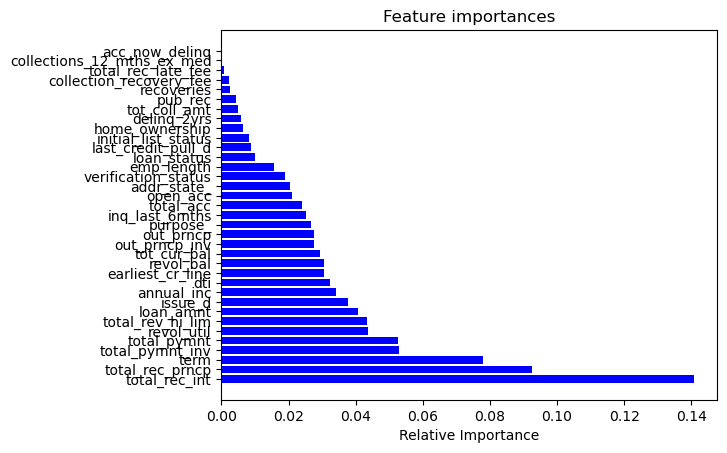

验证集准确率: 0.73


In [3]:
# 导入必要的库
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
import numpy as np
import matplotlib.pyplot as plt

# 目标列名为'grade'
# 首先分割出10%的数据作为测试集
X_train, X_test, y_train, y_test = train_test_split(
    df.drop('grade', axis=1),
    df['grade'],
    test_size=0.1,  # 10% 作为测试集
    random_state=123
)

# 然后从剩余的90%中分割出20%作为验证集
X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train,
    test_size=0.2,  # 从剩余的90%中再分割出20%作为验证集
    random_state=123
)

# 创建随机森林分类器实例，并设置指定的参数
rf_classifier2 = RandomForestClassifier(
    n_estimators=132, 
    criterion='entropy', 
    max_depth=39, 
    max_features='sqrt', 
    min_samples_leaf=2, 
    min_samples_split=6, 
    random_state=111,  # 确保结果的可复现性
    class_weight='balanced'
)

# 训练模型
rf_classifier2.fit(X_train, y_train)

# 获取特征重要性并绘图
feature_importances = rf_classifier2.feature_importances_
indices = np.argsort(feature_importances)[::-1]

plt.figure()
plt.title("Feature importances")
plt.barh(range(len(indices)), feature_importances[indices], color='b', align='center')
# 使用 X_train 的列名作为 y 轴的标签
plt.yticks(range(len(indices)), [X_train.columns[i] for i in indices])
plt.xlabel('Relative Importance')
plt.show()

# 使用验证集进行预测
y_val_pred = rf_classifier2.predict(X_val)
# 计算验证集的准确率
val_accuracy = accuracy_score(y_val, y_val_pred)
print(f"验证集准确率: {val_accuracy:.2f}")

In [4]:
# 使用测试集对模型进行评价
y_test_pred = rf_classifier2.predict(X_test)
# 计算测试集的准确率
test_accuracy = accuracy_score(y_test, y_test_pred)
print(f"测试集准确率: {test_accuracy:.2f}")

测试集准确率: 0.73


In [5]:
from sklearn.metrics import f1_score

# 计算 F1 分数，'weighted' 选项处理多分类问题中的类别不平衡
f1 = f1_score(y_test, y_test_pred, average='weighted')

print(f"测试集的 F1 分数: {f1:.2f}")

测试集的 F1 分数: 0.73
